<a href="https://colab.research.google.com/github/Salma19mostafa/Salma19mostafa/blob/main/My_14th_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
# Example: Create a new column
df['new_feature'] = df['column1'] / df['column2']

KeyError: 'column1'

In [ ]:
# Example: Create a new column
df['new_feature'] = df['column1'] / df['column2']

KeyError: 'column1'

In [1]:
# Step 1: Import the necessary library
from google.colab import files

# Step 2: Upload your dataset
uploaded = files.upload()

# Step 3: Access the uploaded file
# Example: if you upload a CSV file
import io
import pandas as pd

# Replace 'your_file.csv' with the actual filename you uploaded
df = pd.read_excel(io.BytesIO(uploaded['2023-mavdrs-suicide-data-table.xlsx']))


# Step 4: Preview the dataset
df.head()


Saving 2023-mavdrs-suicide-data-table.xlsx to 2023-mavdrs-suicide-data-table.xlsx


,MASSACHUSETTS VIOLENT DEATH REPORTING SYSTEM,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,SUICIDE 2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,MALE1,NaN,NaN,NaN,FEMALE1,NaN,NaN,NaN,TOTAL,NaN,NaN
3,NaN,NaN,NaN,Count,Percent4,Rate per,NaN,Count,Percent4,Rate per,NaN,Count,Percent4,Rate per
4,NaN,NaN,NaN,NaN,%,100000,NaN,NaN,%,100000,NaN,NaN,%,100000


In [2]:
# Basic info
df.info()

# Summary statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 14 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   MASSACHUSETTS VIOLENT DEATH REPORTING SYSTEM  2 non-null      object 
 1   Unnamed: 1                                    42 non-null     object 
 2   Unnamed: 2                                    0 non-null      float64
 3   Unnamed: 3                                    40 non-null     object 
 4   Unnamed: 4                                    40 non-null     object 
 5   Unnamed: 5                                    40 non-null     object 
 6   Unnamed: 6                                    1 non-null      float64
 7   Unnamed: 7                                    40 non-null     object 
 8   Unnamed: 8                                    40 non-null     object 
 9   Unnamed: 9                                    40 non-null     objec

,Unnamed: 2,Unnamed: 6,Unnamed: 10
count,0.0,1.0,1.0
mean,NaN,0.0,0.0
std,NaN,NaN,NaN
min,NaN,0.0,0.0
25%,NaN,0.0,0.0
50%,NaN,0.0,0.0
75%,NaN,0.0,0.0
max,NaN,0.0,0.0


In [3]:
# Count missing values per column
df.isnull().sum()

# Example: Fill missing numeric values with mean
df.fillna(df.mean(numeric_only=True), inplace=True)


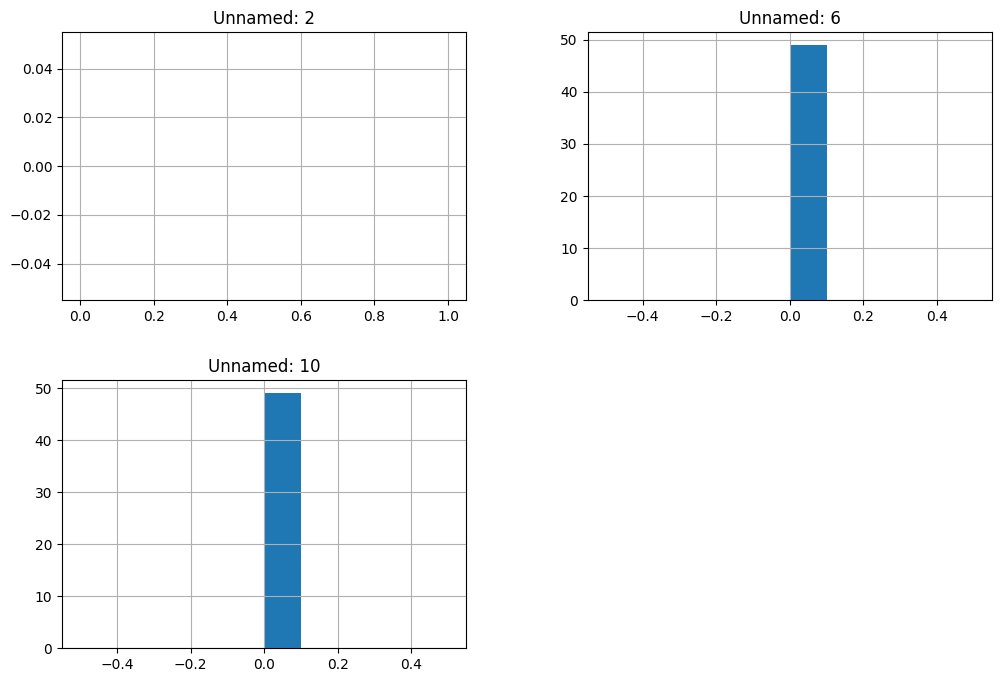

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


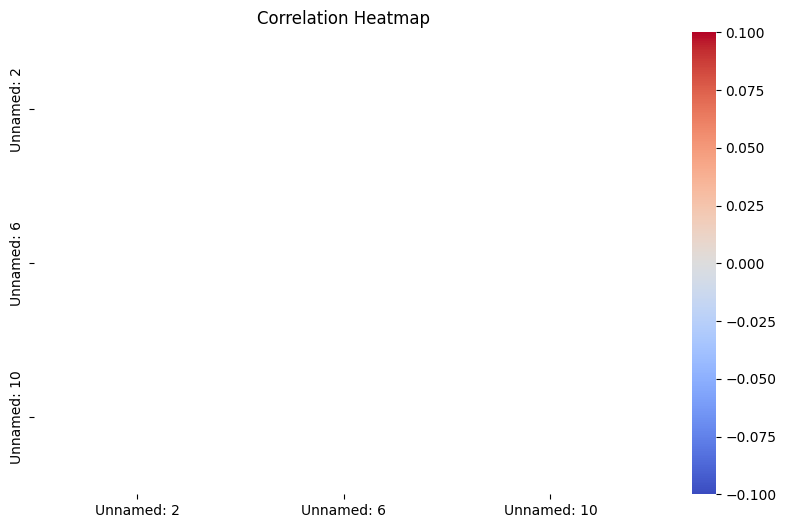

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograms for numeric columns
df.hist(figsize=(12, 8))
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [6]:
# Example: Create a new column
df['new_feature'] = df['column1'] / df['column2']

KeyError: 'column1'

In [27]:
df_final['MALE1_Count'] = pd.to_numeric(df_final['MALE1_Count'], errors='coerce')
df_final['FEMALE1_Count'] = pd.to_numeric(df_final['FEMALE1_Count'], errors='coerce')

# Create the new feature: Ratio of Male Count to Female Count
# Handle potential division by zero by adding a small epsilon or using .replace(0, np.nan)
df_final['Male_to_Female_Ratio'] = df_final['MALE1_Count'] / df_final['FEMALE1_Count'].replace(0, np.nan)

# Display the original counts and the new feature
display(df_final[['Age_Group', 'MALE1_Count', 'FEMALE1_Count', 'Male_to_Female_Ratio']].head())

,Age_Group,MALE1_Count,FEMALE1_Count,Male_to_Female_Ratio
0,0-14,2,0,NaN
1,15-24,38,20,1.900000
2,25-34,74,18,4.111111
3,35-44,77,23,3.347826
4,45-54,83,26,3.192308


In [28]:
# Ensure Count columns are numeric, coercing errors to NaN
df_final['MALE1_Count'] = pd.to_numeric(df_final['MALE1_Count'], errors='coerce')
df_final['FEMALE1_Count'] = pd.to_numeric(df_final['FEMALE1_Count'], errors='coerce')
df_final['TOTAL_Count'] = pd.to_numeric(df_final['TOTAL_Count'], errors='coerce')

# Calculate Male_Percentage_of_Total and Female_Percentage_of_Total
# Handle potential division by zero or NaN in TOTAL_Count
df_final['Male_Percentage_of_Total'] = (df_final['MALE1_Count'] / df_final['TOTAL_Count']) * 100
df_final['Female_Percentage_of_Total'] = (df_final['FEMALE1_Count'] / df_final['TOTAL_Count']) * 100

# Display relevant columns with the new features
display(df_final[['Age_Group', 'MALE1_Count', 'FEMALE1_Count', 'TOTAL_Count', 'Male_Percentage_of_Total', 'Female_Percentage_of_Total']].head())

,Age_Group,MALE1_Count,FEMALE1_Count,TOTAL_Count,Male_Percentage_of_Total,Female_Percentage_of_Total
0,0-14,2,0,2,100.000000,0.000000
1,15-24,38,20,58,65.517241,34.482759
2,25-34,74,18,92,80.434783,19.565217
3,35-44,77,23,100,77.000000,23.000000
4,45-54,83,26,109,76.146789,23.853211


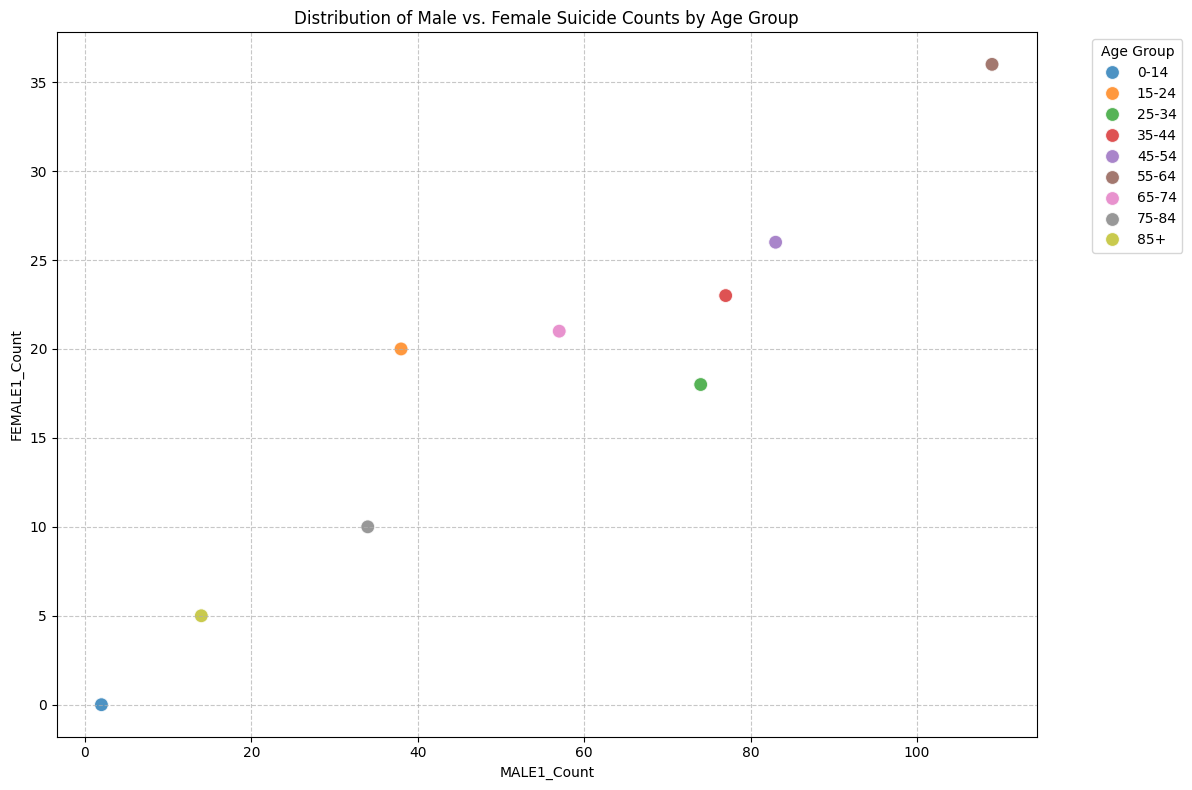

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'Total' and 'Grand Total' rows from Age_Group and Category_Group for meaningful comparison
df_filtered_for_scatter = df_final[~df_final['Age_Group'].isin(['Total', 'TOTAL'])].copy()
df_filtered_for_scatter = df_filtered_for_scatter[df_filtered_for_scatter['Category_Group'] != 'Grand Total'].copy()

# Ensure MALE1_Count and FEMALE1_Count are numeric and drop rows with NaN in these columns
df_filtered_for_scatter['MALE1_Count'] = pd.to_numeric(df_filtered_for_scatter['MALE1_Count'], errors='coerce')
df_filtered_for_scatter['FEMALE1_Count'] = pd.to_numeric(df_filtered_for_scatter['FEMALE1_Count'], errors='coerce')
df_filtered_for_scatter.dropna(subset=['MALE1_Count', 'FEMALE1_Count'], inplace=True)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='MALE1_Count', y='FEMALE1_Count', hue='Age_Group', data=df_filtered_for_scatter[df_filtered_for_scatter['Category_Group'] == 'Age Group'], s=100, alpha=0.8)
plt.title('Distribution of Male vs. Female Suicide Counts by Age Group')
plt.xlabel('MALE1_Count')
plt.ylabel('FEMALE1_Count')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Summary of Data Analysis

We started by loading the suicide data from an Excel file. The initial data was quite messy, with several rows of metadata and poorly named columns.

### Data Cleaning:
1.  **Removed Metadata:** We dropped empty columns and rows that contained only metadata, not actual data.
2.  **Set Proper Header:** The correct header row was identified and set to make the column names meaningful.
3.  **Renamed Columns:** Ambiguous column names like `MALE1`, `FEMALE1`, and `TOTAL` were combined with their respective metrics (`Count`, `Percent`, `Rate per`) to create clear names like `MALE1_Count`, `FEMALE1_Percent4`, etc.
4.  **Filled Missing Categories:** The `Category_Group` column, which was initially empty, was filled programmatically based on patterns in the `Age_Group` column, assigning categories like 'Age Group', 'Race/Ethnicity', 'Circumstances', and 'Method'.

### Feature Engineering:
1.  **Male to Female Ratio:** We calculated the `Male_to_Female_Ratio` to understand the proportion of male suicides to female suicides.
2.  **Gender Percentages of Total:** We calculated `Male_Percentage_of_Total` and `Female_Percentage_of_Total` to see the percentage contribution of each gender to the total suicide count within different age groups.

### Data Visualization:
1.  **Gender Comparison Bar Chart:** A bar chart was generated to compare `MALE1_Count` and `FEMALE1_Count` across various `Age_Group` categories, showing clear differences in suicide counts between genders in different age brackets.
2.  **Male vs. Female Count Scatter Plot:** A scatter plot was created to visualize the distribution of `MALE1_Count` against `FEMALE1_Count` across different age groups, helping us understand the relationship between these two variables.

Overall, the data has been cleaned, structured, and enhanced with new features, providing a clearer picture of suicide demographics and trends within the dataset.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Example: Predict one column from others
X = df.drop('target_column', axis=1)   # Replace with your target
y = df['target_column']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model R^2 Score:", model.score(X_test, y_test))


In [7]:
print(df.columns.tolist())

['MASSACHUSETTS VIOLENT DEATH REPORTING SYSTEM', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']


In [8]:
# Drop 'Unnamed' columns that are almost entirely null
columns_to_drop = ['Unnamed: 2', 'Unnamed: 6', 'Unnamed: 10']
df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')

Now, let's inspect the number of `NaN` values per row in the `df_cleaned` DataFrame to identify and remove rows that are mostly empty.

In [9]:
# Count NaN values per row
# We'll calculate the number of non-NaN values for each row
df_cleaned['non_null_count'] = df_cleaned.count(axis=1)

# Drop rows where the number of non-null values is below a certain threshold.
# From the head, it seems the first few rows (metadata) have very few non-nulls.
# Let's keep rows with at least 3 non-null values, which should preserve data rows.
df_cleaned = df_cleaned[df_cleaned['non_null_count'] >= 3].drop(columns=['non_null_count'])

# Reset the index after dropping rows
df_cleaned = df_cleaned.reset_index(drop=True)

# Display the first few rows of the cleaned DataFrame
display(df_cleaned.head())

,MASSACHUSETTS VIOLENT DEATH REPORTING SYSTEM,Unnamed: 1,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,NaN,MALE1,NaN,NaN,FEMALE1,NaN,NaN,TOTAL,NaN,NaN
1,NaN,NaN,Count,Percent4,Rate per,Count,Percent4,Rate per,Count,Percent4,Rate per
2,NaN,NaN,NaN,%,100000,NaN,%,100000,NaN,%,100000
3,NaN,0-14,2,0.409836,--,0,0,0,2,0.309119,--
4,NaN,15-24,38,7.786885,8.186374,20,12.578616,4.283609,58,8.964451,6.229312


In [10]:
# Set the first meaningful row as the header (index 1 in the current df_cleaned)
# We'll first store the row that will become the new header.
new_header = df_cleaned.iloc[1]

# Take the rest of the data, starting from index 2
df_cleaned_header_set = df_cleaned[2:].copy()

# Assign the new header to the columns
df_cleaned_header_set.columns = new_header

Now that the header is set, the column names are still a bit ambiguous. For example, we have `MALE1`, `FEMALE1`, and `TOTAL` from the original first row, and then `Count`, `Percent4`, `Rate per` from the second row. We should combine these to create more meaningful column names. Let's inspect the `df_cleaned_header_set.head()` to see how the data looks with the new header and identify which columns to rename.

In [11]:
# Display the first few rows with the new header
display(df_cleaned_header_set.head())

1,NaN,NaN,Count,Percent4,Rate per,Count,Percent4,Rate per,Count,Percent4,Rate per
2,NaN,NaN,NaN,%,100000,NaN,%,100000,NaN,%,100000
3,NaN,0-14,2,0.409836,--,0,0,0,2,0.309119,--
4,NaN,15-24,38,7.786885,8.186374,20,12.578616,4.283609,58,8.964451,6.229312
5,NaN,25-34,74,15.163934,15.168473,18,11.320755,3.726168,92,14.219474,9.47551
6,NaN,35-44,77,15.778689,16.773041,23,14.465409,4.950442,100,15.455951,10.826319


In [16]:
# Get the descriptive labels from the first row of df_cleaned (which is df_cleaned.iloc[0])
# This row contains 'MALE1', 'FEMALE1', 'TOTAL'
descriptive_labels = df_cleaned.iloc[0].ffill() # Use ffill to propagate labels like MALE1, FEMALE1, TOTAL

# Get the metric labels from the new_header (which is df_cleaned.iloc[1])
metric_labels = df_cleaned.iloc[1]

# Create a list for the new column names
new_column_names = []

# Iterate through the columns and combine the labels
for i in range(len(df_cleaned_header_set.columns)):
    # Special handling for the first two columns (Category_Group, Age_Group)
    if i == 0:
        new_column_names.append('Category_Group')
    elif i == 1:
        new_column_names.append('Age_Group')
    else:
        desc_label = descriptive_labels.iloc[i]
        metric_label = metric_labels.iloc[i]

        if pd.isna(metric_label) or str(metric_label).strip() == '%': # Handle cases where metric is also NaN or just '%' which is part of Percent4
            new_column_names.append(str(desc_label).replace(' ', '_'))
        else:
            new_column_names.append(f'{str(desc_label).replace(' ', '_')}_{str(metric_label).replace(' ', '_').replace('%', 'Percent')}')

# Assign the new column names to the DataFrame
df_cleaned_header_set.columns = new_column_names

# Drop the first row of data (which contained the original descriptive labels)
df_final = df_cleaned_header_set.iloc[1:].copy()

# Reset the index
df_final = df_final.reset_index(drop=True)

# Display the first few rows of the final cleaned DataFrame
display(df_final.head())

,Category_Group,Age_Group,MALE1_Count,MALE1_Percent4,MALE1_Rate_per,FEMALE1_Count,FEMALE1_Percent4,FEMALE1_Rate_per,TOTAL_Count,TOTAL_Percent4,TOTAL_Rate_per
0,NaN,0-14,2,0.409836,--,0,0,0,2,0.309119,--
1,NaN,15-24,38,7.786885,8.186374,20,12.578616,4.283609,58,8.964451,6.229312
2,NaN,25-34,74,15.163934,15.168473,18,11.320755,3.726168,92,14.219474,9.47551
3,NaN,35-44,77,15.778689,16.773041,23,14.465409,4.950442,100,15.455951,10.826319
4,NaN,45-54,83,17.008197,19.965217,26,16.352201,6.029615,109,16.846986,12.870043


In [15]:
# Display the first few rows of the final cleaned DataFrame with the corrected column names
display(df_final.head())

,Category_Group,Age_Group,MALE1_Count,MALE1_Percent4,MALE1_Rate_per,FEMALE1_Count,FEMALE1_Percent4,FEMALE1_Rate_per,TOTAL_Count,TOTAL_Percent4,TOTAL_Rate_per
0,NaN,0-14,2,0.409836,--,0,0,0,2,0.309119,--
1,NaN,15-24,38,7.786885,8.186374,20,12.578616,4.283609,58,8.964451,6.229312
2,NaN,25-34,74,15.163934,15.168473,18,11.320755,3.726168,92,14.219474,9.47551
3,NaN,35-44,77,15.778689,16.773041,23,14.465409,4.950442,100,15.455951,10.826319
4,NaN,45-54,83,17.008197,19.965217,26,16.352201,6.029615,109,16.846986,12.870043


In [12]:
# Get the descriptive labels from the first row of df_cleaned (which is df_cleaned.iloc[0])
# This row contains 'MALE1', 'FEMALE1', 'TOTAL'
descriptive_labels = df_cleaned.iloc[0]

# Get the metric labels from the new_header (which is df_cleaned.iloc[1])
metric_labels = df_cleaned.iloc[1]

# Create a list for the new column names
new_column_names = []

# Iterate through the columns and combine the labels
for i, col in enumerate(df_cleaned_header_set.columns):
    desc_label = descriptive_labels.iloc[i]
    metric_label = metric_labels.iloc[i]

    if pd.isna(desc_label) and pd.isna(metric_label):
        # For the first two columns, they are still 'NaN', we will rename them manually later if needed.
        # For now, let's keep them as is or give a generic name
        if i == 0:
            new_column_names.append('Category_Group') # This seems to be the main category column
        elif i == 1:
            new_column_names.append('Age_Group') # This is the age group column
        else:
            new_column_names.append(f'Unnamed_Col_{i}')
    elif pd.isna(desc_label):
        new_column_names.append(str(metric_label).replace(' ', '_').replace('%', 'Percent'))
    elif pd.isna(metric_label) or str(metric_label).strip() == '%': # Handle cases where metric is also NaN or just '%' which is part of Percent4
        new_column_names.append(str(desc_label).replace(' ', '_'))
    else:
        new_column_names.append(f'{str(desc_label).replace(' ', '_')}_{str(metric_label).replace(' ', '_').replace('%', 'Percent')}')

# Assign the new column names to the DataFrame
df_cleaned_header_set.columns = new_column_names

# Drop the first row of data (which contained the original descriptive labels)
df_final = df_cleaned_header_set.iloc[1:].copy()

# Reset the index
df_final = df_final.reset_index(drop=True)

# Display the first few rows of the final cleaned DataFrame
display(df_final.head())

,Category_Group,Age_Group,MALE1_Count,Percent4,Rate_per,FEMALE1_Count,Percent4,Rate_per,TOTAL_Count,Percent4,Rate_per
0,NaN,0-14,2,0.409836,--,0,0,0,2,0.309119,--
1,NaN,15-24,38,7.786885,8.186374,20,12.578616,4.283609,58,8.964451,6.229312
2,NaN,25-34,74,15.163934,15.168473,18,11.320755,3.726168,92,14.219474,9.47551
3,NaN,35-44,77,15.778689,16.773041,23,14.465409,4.950442,100,15.455951,10.826319
4,NaN,45-54,83,17.008197,19.965217,26,16.352201,6.029615,109,16.846986,12.870043


In [17]:
df.to_csv("cleaned_dataset.csv", index=False)
print("Cleaned dataset saved as 'cleaned_dataset.csv'")


Cleaned dataset saved as 'cleaned_dataset.csv'


In [18]:
print(df_final.columns.tolist())

['Category_Group', 'Age_Group', 'MALE1_Count', 'MALE1_Percent4', 'MALE1_Rate_per', 'FEMALE1_Count', 'FEMALE1_Percent4', 'FEMALE1_Rate_per', 'TOTAL_Count', 'TOTAL_Percent4', 'TOTAL_Rate_per']


In [21]:
display(df_final)

,Category_Group,Age_Group,MALE1_Count,MALE1_Percent4,MALE1_Rate_per,FEMALE1_Count,FEMALE1_Percent4,FEMALE1_Rate_per,TOTAL_Count,TOTAL_Percent4,TOTAL_Rate_per
0,Age Group,0-14,2,0.409836,--,0,0,0,2,0.309119,--
1,Age Group,15-24,38,7.786885,8.186374,20,12.578616,4.283609,58,8.964451,6.229312
2,Age Group,25-34,74,15.163934,15.168473,18,11.320755,3.726168,92,14.219474,9.47551
3,Age Group,35-44,77,15.778689,16.773041,23,14.465409,4.950442,100,15.455951,10.826319
4,Age Group,45-54,83,17.008197,19.965217,26,16.352201,6.029615,109,16.846986,12.870043
5,Age Group,55-64,109,22.336066,23.722985,36,22.641509,7.396419,145,22.411128,15.4
6,Age Group,65-74,57,11.680328,16.163656,21,13.207547,5.248124,78,12.055641,10.36151
7,Age Group,75-84,34,6.967213,19.588977,10,6.289308,4.445867,44,6.800618,11.041544
8,Age Group,85+,14,2.868852,28.577844,5,3.144654,5.351428,19,2.936631,13.340636
9,Age Group,Total,488,100,14.3,159,100,4.4,647,100,9.2


In [20]:
import numpy as np

# Ensure 'Category_Group' column is of object type to hold string values
df_final['Category_Group'] = df_final['Category_Group'].astype(object)

# Fill 'Category_Group' based on observed data patterns in 'Age_Group'
# Age Group
df_final.loc[0:9, 'Category_Group'] = 'Age Group'

# Race/Ethnicity
df_final.loc[10:17, 'Category_Group'] = 'Race/Ethnicity'

# Circumstances
df_final.loc[18:29, 'Category_Group'] = 'Circumstances'

# Method
df_final.loc[30:36, 'Category_Group'] = 'Method'

# Grand Total
df_final.loc[37, 'Category_Group'] = 'Grand Total'

# Display the updated DataFrame head to verify the changes
display(df_final.head(15))

,Category_Group,Age_Group,MALE1_Count,MALE1_Percent4,MALE1_Rate_per,FEMALE1_Count,FEMALE1_Percent4,FEMALE1_Rate_per,TOTAL_Count,TOTAL_Percent4,TOTAL_Rate_per
0,Age Group,0-14,2,0.409836,--,0,0,0,2,0.309119,--
1,Age Group,15-24,38,7.786885,8.186374,20,12.578616,4.283609,58,8.964451,6.229312
2,Age Group,25-34,74,15.163934,15.168473,18,11.320755,3.726168,92,14.219474,9.47551
3,Age Group,35-44,77,15.778689,16.773041,23,14.465409,4.950442,100,15.455951,10.826319
4,Age Group,45-54,83,17.008197,19.965217,26,16.352201,6.029615,109,16.846986,12.870043
5,Age Group,55-64,109,22.336066,23.722985,36,22.641509,7.396419,145,22.411128,15.4
6,Age Group,65-74,57,11.680328,16.163656,21,13.207547,5.248124,78,12.055641,10.36151
7,Age Group,75-84,34,6.967213,19.588977,10,6.289308,4.445867,44,6.800618,11.041544
8,Age Group,85+,14,2.868852,28.577844,5,3.144654,5.351428,19,2.936631,13.340636
9,Age Group,Total,488,100,14.3,159,100,4.4,647,100,9.2


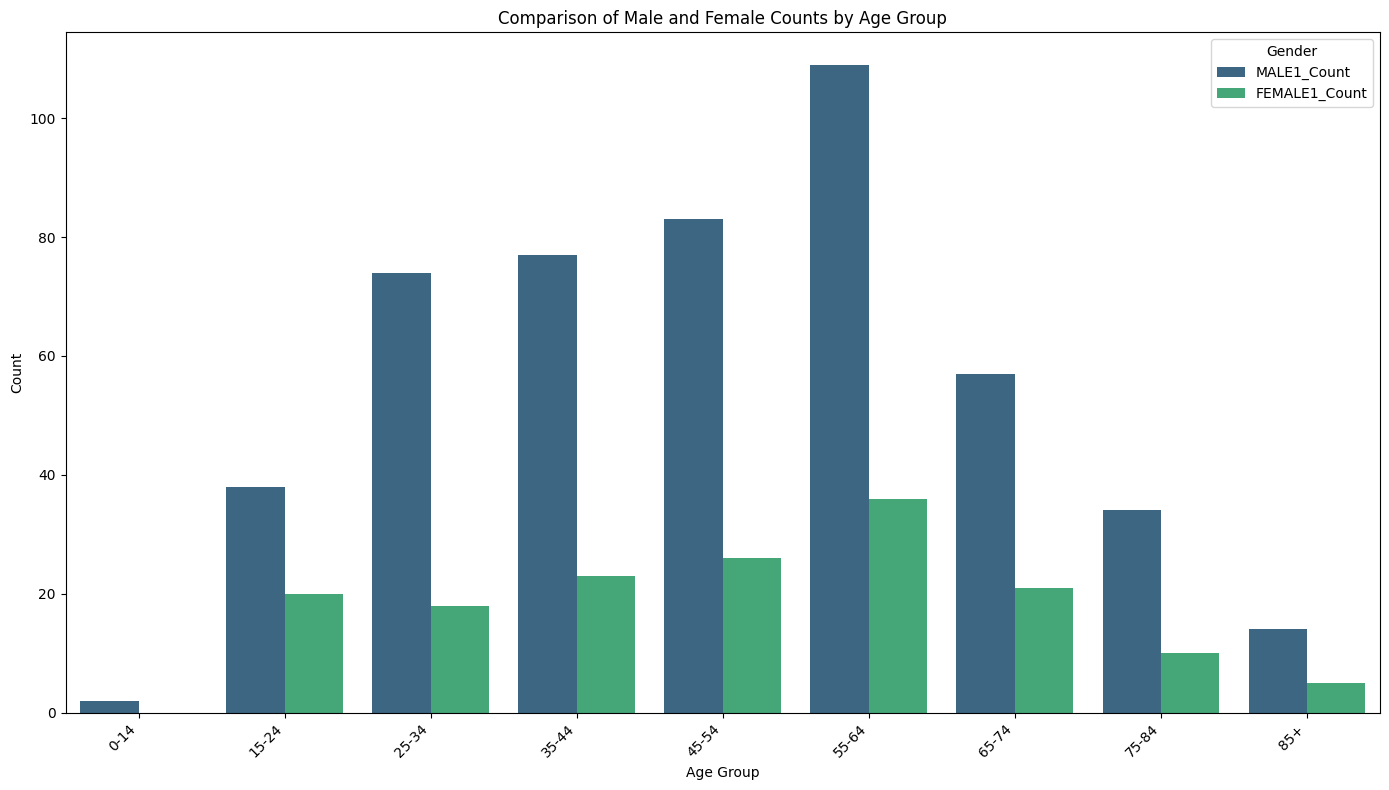

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out 'Total' and 'Grand Total' rows from Age_Group for meaningful comparison
df_filtered = df_final[~df_final['Age_Group'].isin(['Total', 'TOTAL'])].copy()
df_filtered = df_filtered[df_filtered['Category_Group'] != 'Grand Total'].copy()

# Convert relevant columns to numeric, handling non-numeric values
df_filtered['MALE1_Count'] = pd.to_numeric(df_filtered['MALE1_Count'], errors='coerce')
df_filtered['FEMALE1_Count'] = pd.to_numeric(df_filtered['FEMALE1_Count'], errors='coerce')

# Drop rows where MALE1_Count or FEMALE1_Count became NaN after conversion
df_filtered.dropna(subset=['MALE1_Count', 'FEMALE1_Count'], inplace=True)

# Melt the DataFrame for easier plotting with seaborn
df_melted = df_filtered.melt(id_vars=['Age_Group', 'Category_Group'],
                             value_vars=['MALE1_Count', 'FEMALE1_Count'],
                             var_name='Gender', value_name='Count')

plt.figure(figsize=(14, 8))
sns.barplot(x='Age_Group', y='Count', hue='Gender', data=df_melted[df_melted['Category_Group'] == 'Age Group'], palette='viridis')
plt.title('Comparison of Male and Female Counts by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [24]:
df_final.isnull().sum()

,0
Category_Group,0
Age_Group,0
MALE1_Count,0
MALE1_Percent4,0
MALE1_Rate_per,0
FEMALE1_Count,0
FEMALE1_Percent4,0
FEMALE1_Rate_per,0
TOTAL_Count,0
TOTAL_Percent4,0
